# 🧬 Projet : Recommandation des Maladies-Gènes par Prédiction des Liens
## 📏 Phase 5 — Méthodes Baseline (Heuristiques)

---

### 🎯 Objectif de cette phase
Implémenter et évaluer **4 méthodes heuristiques** de prédiction de liens :

| Méthode | Idée principale | Formule |
|---|---|---|
| **Common Neighbors** | Nb de voisins communs | $|N(u) \cap N(v)|$ |
| **Jaccard** | CN normalisé entre 0 et 1 | $\frac{|N(u) \cap N(v)|}{|N(u) \cup N(v)|}$ |
| **Adamic-Adar** | CN pondéré (pénalise les hubs) | $\sum_{w} \frac{1}{\log(|N(w)|)}$ |
| **Resource Allocation** | Comme AA mais sans log | $\sum_{w} \frac{1}{|N(w)|}$ |

---

### 📖 Pourquoi ces méthodes ?
Ces méthodes servent de **référence** (baseline). Si notre modèle d'IA (Phase 6)
n'est pas meilleur que ces heuristiques simples, il faut revoir l'approche.
Elles sont aussi très rapides à calculer et faciles à interpréter.

## ⚙️ Cellule 1 — Importation des bibliothèques

In [10]:
import os
import pickle
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import math
import time

from sklearn.metrics import roc_auc_score, roc_curve, average_precision_score

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (13, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')

print('✅ Bibliothèques importées !')

✅ Bibliothèques importées !


## 📁 Cellule 2 — Chargement des données (Phase 4)

In [11]:
BASE_DIR    = os.path.abspath(os.path.join(os.getcwd(), '..'))
SPLIT_DIR   = os.path.join(BASE_DIR, 'data',    'splits')
RESULTS_DIR = os.path.join(BASE_DIR, 'results')
FIG_DIR     = os.path.join(BASE_DIR, 'results', 'figures')

os.makedirs(FIG_DIR,     exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

with open(os.path.join(SPLIT_DIR, 'G_train.pkl'), 'rb') as f:
    G_train = pickle.load(f)

df_train = pd.read_csv(os.path.join(SPLIT_DIR, 'train_data.csv'))
df_test  = pd.read_csv(os.path.join(SPLIT_DIR, 'test_data.csv'))

print('✅ Données chargées !')
print(f'   Graphe train : {G_train.number_of_nodes():,} nœuds, {G_train.number_of_edges():,} arêtes')
print(f'   Test set     : {len(df_test):,} exemples')

✅ Données chargées !
   Graphe train : 16,555 nœuds, 12,752 arêtes
   Test set     : 6,376 exemples


## 🔧 Cellule 3 — Implémentation des 4 méthodes

> On implémente manuellement les formules pour bien comprendre
> ce que chaque méthode calcule

In [12]:
def preferential_attachment(G, u, v):
    return float(G.degree(u) * G.degree(v))


def common_neighbors_bipartite(G, gene_node, disease_node):
    if gene_node not in G or disease_node not in G:
        return 0.0
    diseases_of_gene = set(G.neighbors(gene_node))
    if len(diseases_of_gene) == 0:
        return 0.0
    genes_L2 = set()
    for d in diseases_of_gene:
        genes_L2.update(G.neighbors(d))
    genes_L2.discard(gene_node)
    genes_of_disease = set(G.neighbors(disease_node))
    return float(len(genes_L2 & genes_of_disease))


def jaccard_bipartite(G, gene_node, disease_node):
    if gene_node not in G or disease_node not in G:
        return 0.0
    diseases_of_gene = set(G.neighbors(gene_node))
    if len(diseases_of_gene) == 0:
        return 0.0
    genes_L2 = set()
    for d in diseases_of_gene:
        genes_L2.update(G.neighbors(d))
    genes_L2.discard(gene_node)
    genes_of_disease = set(G.neighbors(disease_node))
    union = genes_L2 | genes_of_disease
    if len(union) == 0:
        return 0.0
    return len(genes_L2 & genes_of_disease) / len(union)


def adamic_adar_bipartite(G, gene_node, disease_node):
    if gene_node not in G or disease_node not in G:
        return 0.0
    diseases_of_gene = set(G.neighbors(gene_node))
    if len(diseases_of_gene) == 0:
        return 0.0
    genes_L2 = set()
    for d in diseases_of_gene:
        genes_L2.update(G.neighbors(d))
    genes_L2.discard(gene_node)
    genes_of_disease = set(G.neighbors(disease_node))
    common = genes_L2 & genes_of_disease
    score = 0.0
    for g in common:
        deg = G.degree(g)
        if deg > 1:
            score += 1.0 / math.log(deg)
    return score


def resource_allocation_bipartite(G, gene_node, disease_node):
    if gene_node not in G or disease_node not in G:
        return 0.0
    diseases_of_gene = set(G.neighbors(gene_node))
    if len(diseases_of_gene) == 0:
        return 0.0
    genes_L2 = set()
    for d in diseases_of_gene:
        genes_L2.update(G.neighbors(d))
    genes_L2.discard(gene_node)
    genes_of_disease = set(G.neighbors(disease_node))
    common = genes_L2 & genes_of_disease
    score = 0.0
    for g in common:
        deg = G.degree(g)
        if deg > 0:
            score += 1.0 / deg
    return score


def combined_score(G, gene_node, disease_node):
    max_deg = max((G.degree(n) for n in G.nodes()), default=1)
    pa_norm = (G.degree(gene_node) * G.degree(disease_node)) / (max_deg * max_deg + 1e-9)
    cn = common_neighbors_bipartite(G, gene_node, disease_node)
    cn_norm = cn / (max_deg + 1e-9)
    return 0.6 * pa_norm + 0.4 * cn_norm


print('✅ 6 méthodes définies (PA, CN, Jaccard, Adamic-Adar, Resource Alloc., Combiné)')

✅ 6 méthodes définies (PA, CN, Jaccard, Adamic-Adar, Resource Alloc., Combiné)


## 🧪 Cellule 4 — Test rapide sur des exemples simples

> Vérification que nos fonctions marchent bien avant de les appliquer au graphe complet

In [13]:
print('🧪 TEST RAPIDE :\n')
print(f'{"Paire":<40} {"PA":>8} {"CN":>6} {"Jac":>7} {"AA":>7} {"Comb":>7} {"Réel":>6}')
print('─' * 80)

for _, row in df_test[df_test.label==1].head(3).iterrows():
    u, v = row['node1'], row['node2']
    pa = preferential_attachment(G_train, u, v)
    cn = common_neighbors_bipartite(G_train, u, v)
    jc = jaccard_bipartite(G_train, u, v)
    aa = adamic_adar_bipartite(G_train, u, v)
    comb = combined_score(G_train, u, v)
    print(f'{u[:16]+"↔"+v[:16]:<40} {pa:>8.1f} {cn:>6.1f} {jc:>7.4f} {aa:>7.3f} {comb:>7.4f} {"✅ 1":>6}')

print()
for _, row in df_test[df_test.label==0].head(3).iterrows():
    u, v = row['node1'], row['node2']
    pa = preferential_attachment(G_train, u, v)
    cn = common_neighbors_bipartite(G_train, u, v)
    jc = jaccard_bipartite(G_train, u, v)
    aa = adamic_adar_bipartite(G_train, u, v)
    comb = combined_score(G_train, u, v)
    print(f'{u[:16]+"↔"+v[:16]:<40} {pa:>8.1f} {cn:>6.1f} {jc:>7.4f} {aa:>7.3f} {comb:>7.4f} {"❌ 0":>6}')

🧪 TEST RAPIDE :

Paire                                          PA     CN     Jac      AA    Comb   Réel
────────────────────────────────────────────────────────────────────────────────
G_4204↔D_ORPHA:777                          184.0    0.0  0.0000   0.000  0.0125    ✅ 1
G_26284↔D_OMIM:617565                         0.0    0.0  0.0000   0.000  0.0000    ✅ 1
G_4921↔D_OMIM:618175                          0.0    0.0  0.0000   0.000  0.0000    ✅ 1

G_92002↔D_OMIM:185800                         1.0    0.0  0.0000   0.000  0.0001    ❌ 0
G_8788↔D_ORPHA:169154                         5.0    0.0  0.0000   0.000  0.0003    ❌ 0
G_1029↔D_OMIM:621060                          8.0    0.0  0.0000   0.000  0.0005    ❌ 0


## ⚡ Cellule 5 — Calcul des scores sur tout le jeu de TEST

> On calcule les 4 scores pour chaque paire du jeu de test

In [14]:
print(f'⏳ Calcul des scores sur {len(df_test):,} paires...')

pa_scores, cn_scores, jc_scores = [], [], []
aa_scores, ra_scores, comb_scores = [], [], []
labels = df_test['label'].values

t0 = time.time()
for i, row in df_test.iterrows():
    u, v = row['node1'], row['node2']
    pa_scores.append(preferential_attachment(G_train, u, v))
    cn_scores.append(common_neighbors_bipartite(G_train, u, v))
    jc_scores.append(jaccard_bipartite(G_train, u, v))
    aa_scores.append(adamic_adar_bipartite(G_train, u, v))
    ra_scores.append(resource_allocation_bipartite(G_train, u, v))
    comb_scores.append(combined_score(G_train, u, v))
    if (i+1) % 1000 == 0:
        print(f'   {i+1}/{len(df_test)} traités...')

print(f'\n✅ Terminé en {time.time()-t0:.1f}s')

df_results = df_test.copy()
df_results['score_PA']   = pa_scores
df_results['score_CN']   = cn_scores
df_results['score_JC']   = jc_scores
df_results['score_AA']   = aa_scores
df_results['score_RA']   = ra_scores
df_results['score_COMB'] = comb_scores

df_results.head(8)

⏳ Calcul des scores sur 6,376 paires...
   1000/6376 traités...
   2000/6376 traités...
   3000/6376 traités...
   4000/6376 traités...
   5000/6376 traités...
   6000/6376 traités...

✅ Terminé en 309.6s


,node1,node2,label,score_PA,score_CN,score_JC,score_AA,score_RA,score_COMB
0,G_92002,D_OMIM:185800,0,1.0,0.0,0.0,0.0,0.0,0.000068
1,G_4204,D_ORPHA:777,1,184.0,0.0,0.0,0.0,0.0,0.012494
2,G_8788,D_ORPHA:169154,0,5.0,0.0,0.0,0.0,0.0,0.000340
3,G_1029,D_OMIM:621060,0,8.0,0.0,0.0,0.0,0.0,0.000543
4,G_93035,D_OMIM:618097,0,1.0,0.0,0.0,0.0,0.0,0.000068
5,G_26284,D_OMIM:617565,1,0.0,0.0,0.0,0.0,0.0,0.000000
6,G_4921,D_OMIM:618175,1,0.0,0.0,0.0,0.0,0.0,0.000000
7,G_3239,D_OMIM:113200,1,0.0,0.0,0.0,0.0,0.0,0.000000


## 📊 Cellule 6 — Distribution des scores (positifs vs négatifs)

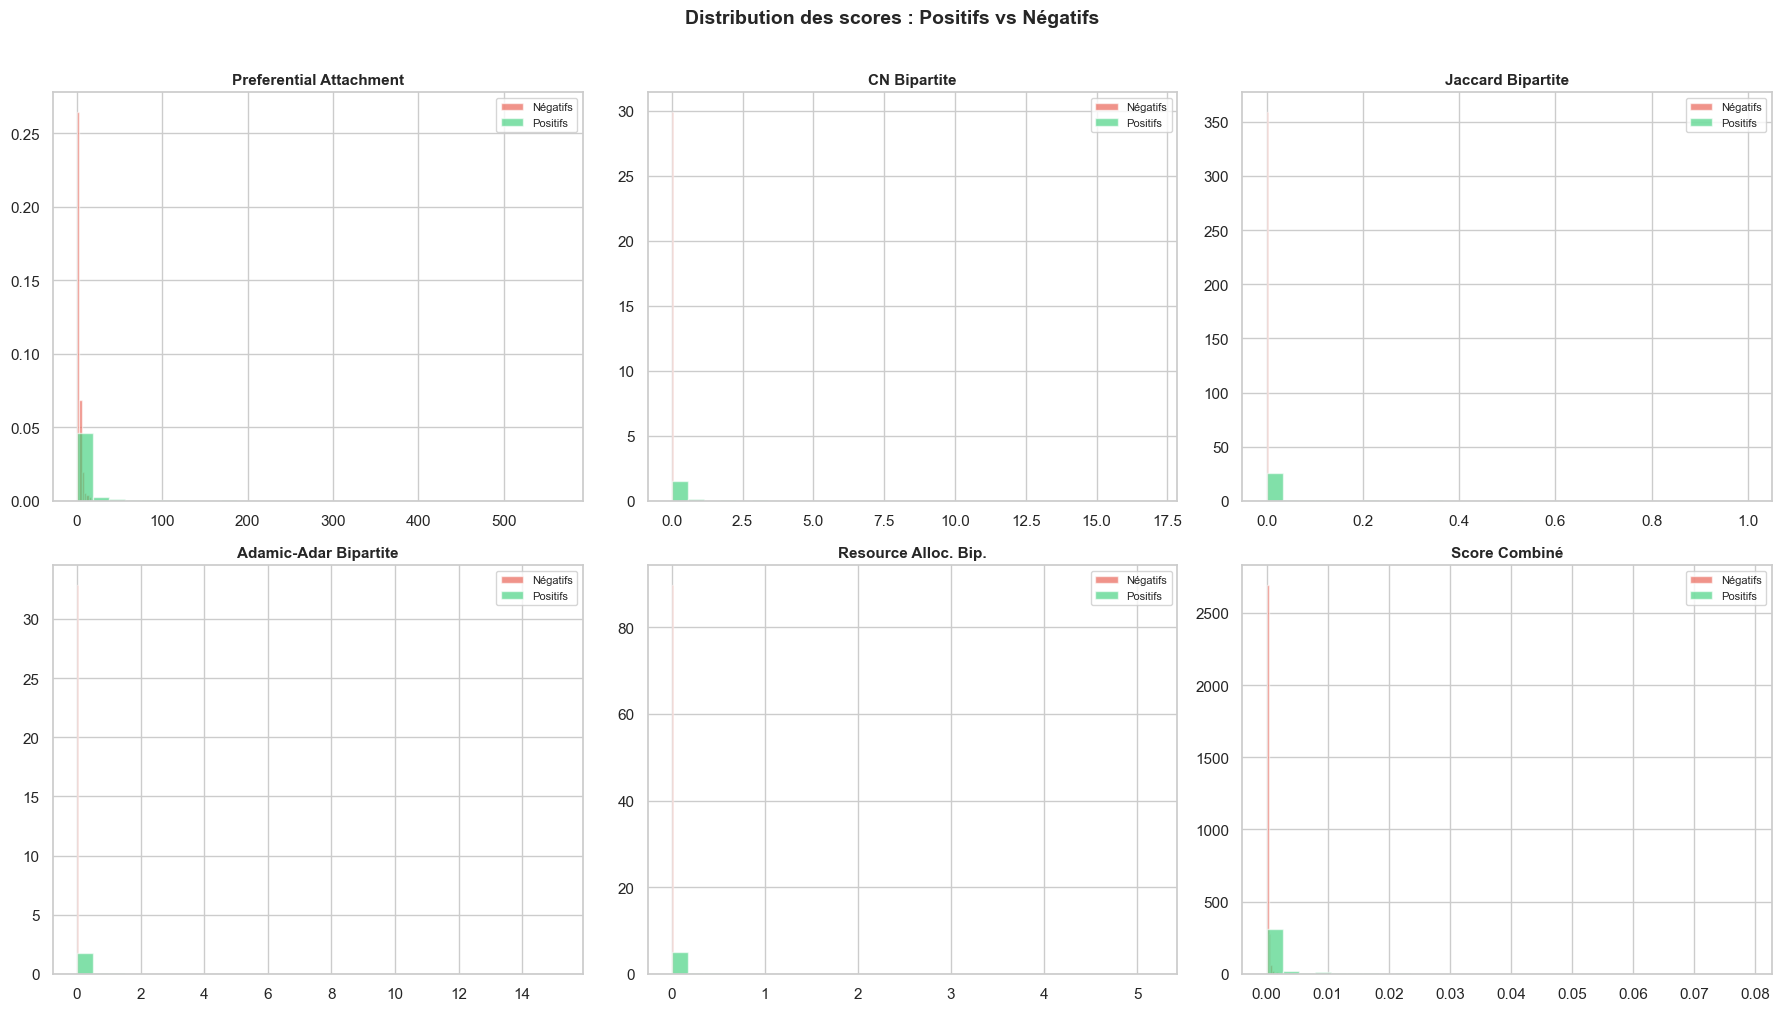

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
methods_plot = [
    ('score_PA',   'Preferential Attachment', axes[0,0]),
    ('score_CN',   'CN Bipartite',            axes[0,1]),
    ('score_JC',   'Jaccard Bipartite',       axes[0,2]),
    ('score_AA',   'Adamic-Adar Bipartite',   axes[1,0]),
    ('score_RA',   'Resource Alloc. Bip.',    axes[1,1]),
    ('score_COMB', 'Score Combiné',           axes[1,2]),
]

for col, name, ax in methods_plot:
    pos_scores = df_results[df_results.label==1][col]
    neg_scores = df_results[df_results.label==0][col]
    ax.hist(neg_scores, bins=30, alpha=0.6, color='#E74C3C', label='Négatifs', density=True)
    ax.hist(pos_scores, bins=30, alpha=0.6, color='#2ECC71', label='Positifs', density=True)
    ax.set_title(name, fontweight='bold', fontsize=11)
    ax.legend(fontsize=8)

plt.suptitle('Distribution des scores : Positifs vs Négatifs', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'baseline_score_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

## 📈 Cellule 7 — Calcul de l'AUC-ROC pour chaque méthode

In [16]:
y_true = df_results['label'].values
score_cols = {
    'Preferential Attachment' : 'score_PA',
    'CN Bipartite'            : 'score_CN',
    'Jaccard Bipartite'       : 'score_JC',
    'Adamic-Adar Bipartite'   : 'score_AA',
    'Resource Alloc. Bip.'    : 'score_RA',
    'Score Combiné'           : 'score_COMB',
}

auc_scores, ap_scores = {}, {}
for name, col in score_cols.items():
    scores = df_results[col].values
    auc_scores[name] = roc_auc_score(y_true, scores)
    ap_scores[name]  = average_precision_score(y_true, scores)

print('═'*55)
print('   📈 AUC-ROC PAR MÉTHODE')
print('═'*55)
for name in auc_scores:
    flag = '⭐' if auc_scores[name] == max(auc_scores.values()) else '  '
    print(f'{flag} {name:<25} AUC={auc_scores[name]:.4f}  AP={ap_scores[name]:.4f}')

best_method = max(auc_scores, key=auc_scores.get)
print(f'\n🏆 Meilleure méthode : {best_method} (AUC={auc_scores[best_method]:.4f})')

═══════════════════════════════════════════════════════
   📈 AUC-ROC PAR MÉTHODE
═══════════════════════════════════════════════════════
   Preferential Attachment   AUC=0.3704  AP=0.5945
   CN Bipartite              AUC=0.5751  AP=0.5752
⭐ Jaccard Bipartite         AUC=0.5751  AP=0.5758
   Adamic-Adar Bipartite     AUC=0.5751  AP=0.5755
   Resource Alloc. Bip.      AUC=0.5750  AP=0.5753
   Score Combiné             AUC=0.3784  AP=0.6197

🏆 Meilleure méthode : Jaccard Bipartite (AUC=0.5751)


## 📉 Cellule 8 — Courbes ROC comparatives

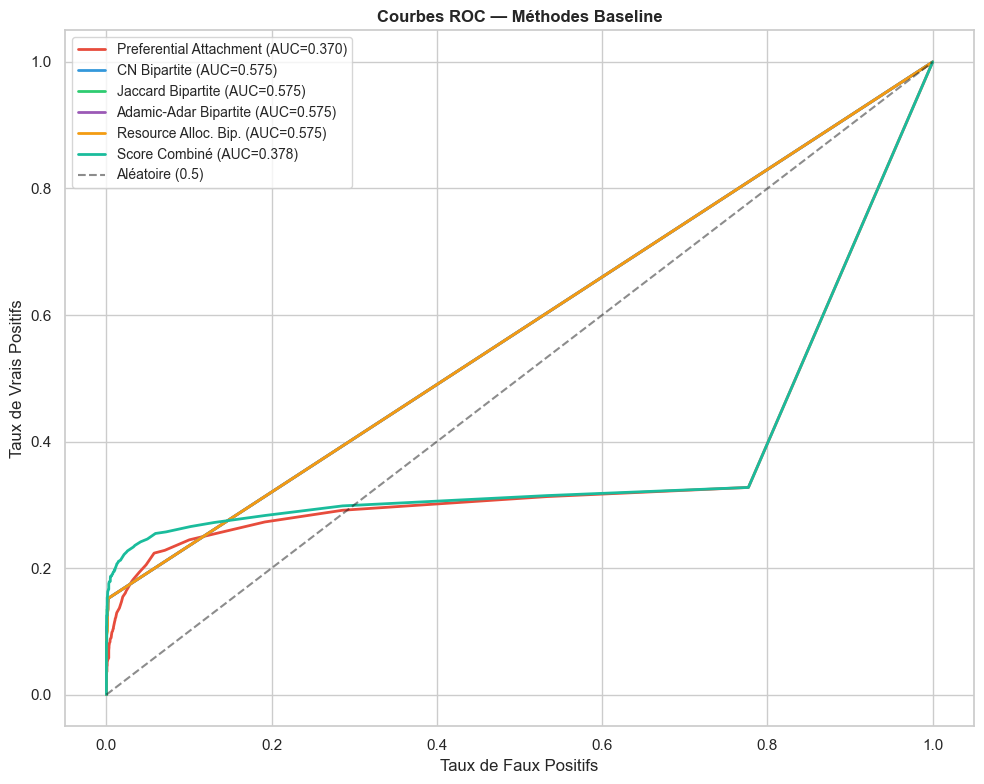

In [17]:
fig, ax = plt.subplots(figsize=(10, 8))
colors_list = ['#E74C3C','#3498DB','#2ECC71','#9B59B6','#F39C12','#1ABC9C']

for (name, col), color in zip(score_cols.items(), colors_list):
    scores = df_results[col].values
    fpr, tpr, _ = roc_curve(y_true, scores)
    auc = auc_scores[name]
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={auc:.3f})')

ax.plot([0,1],[0,1], 'k--', alpha=0.5, label='Aléatoire (0.5)')
ax.set_xlabel('Taux de Faux Positifs')
ax.set_ylabel('Taux de Vrais Positifs')
ax.set_title('Courbes ROC — Méthodes Baseline', fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'baseline_roc_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

## 🎯 Cellule 9 — Précision@K

In [18]:
def precision_at_k(y_true, scores, k):
    idx = np.argsort(scores)[::-1][:k]
    return np.mean(y_true[idx])

K_VALUES = [10, 20, 50, 100]
print('🎯 PRÉCISION@K\n')
pk_results = {}
for name, col in score_cols.items():
    scores = df_results[col].values
    pk_vals = [precision_at_k(y_true, scores, k) for k in K_VALUES]
    pk_results[name] = pk_vals
    print(f'{name:<25}' + ''.join([f'  P@{k}={v:.3f}' for k,v in zip(K_VALUES, pk_vals)]))

🎯 PRÉCISION@K

Preferential Attachment    P@10=1.000  P@20=1.000  P@50=1.000  P@100=1.000
CN Bipartite               P@10=1.000  P@20=1.000  P@50=1.000  P@100=1.000
Jaccard Bipartite          P@10=1.000  P@20=1.000  P@50=1.000  P@100=1.000
Adamic-Adar Bipartite      P@10=1.000  P@20=1.000  P@50=1.000  P@100=1.000
Resource Alloc. Bip.       P@10=1.000  P@20=1.000  P@50=1.000  P@100=1.000
Score Combiné              P@10=1.000  P@20=1.000  P@50=1.000  P@100=1.000


## 📊 Cellule 10 — Tableau comparatif final des méthodes

In [19]:
results_table = pd.DataFrame({
    'Méthode': list(score_cols.keys()),
    'AUC-ROC': [round(auc_scores[n], 4) for n in score_cols],
    'Avg Precision': [round(ap_scores[n], 4) for n in score_cols],
    'P@50': [round(pk_results[n][2], 3) for n in score_cols],
}).sort_values('AUC-ROC', ascending=False)

print('📊 TABLEAU COMPARATIF FINAL')
print(results_table.to_string(index=False))

results_table.to_csv(os.path.join(RESULTS_DIR, 'baseline_metrics.csv'), index=False)
df_results.to_csv(os.path.join(RESULTS_DIR, 'baseline_scores.csv'), index=False)
print('\n💾 Résultats sauvegardés !')

📊 TABLEAU COMPARATIF FINAL
                Méthode  AUC-ROC  Avg Precision  P@50
           CN Bipartite   0.5751         0.5752   1.0
      Jaccard Bipartite   0.5751         0.5758   1.0
  Adamic-Adar Bipartite   0.5751         0.5755   1.0
   Resource Alloc. Bip.   0.5750         0.5753   1.0
          Score Combiné   0.3784         0.6197   1.0
Preferential Attachment   0.3704         0.5945   1.0

💾 Résultats sauvegardés !


## 🔍 Cellule 11 — Analyse des meilleures prédictions

In [21]:
best_col = score_cols[best_method]

df_top20 = (
    df_results[['node1', 'node2', best_col, 'label']]
    .sort_values(best_col, ascending=False)
    .head(20)
)
df_top20.index = range(1, 21)

print(f'🔍 TOP 20 PRÉDICTIONS selon {best_method} :')
print(f'   (✅ = vrai lien confirmé, ❌ = fausse prédiction)\n')
for i, row in df_top20.iterrows():
    status = '✅' if row['label'] == 1 else '❌'
    print(f'  {i:>2}. {status} {row["node1"][:18]:<20} ↔ '
          f'{row["node2"][:18]:<20} score={row[best_col]:.4f}')

tp_in_top20 = df_top20['label'].sum()
print(f'\n📊 Vrais positifs dans le top 20 : {tp_in_top20}/20')
print(f'   Précision@20 = {tp_in_top20/20:.1%}')

🔍 TOP 20 PRÉDICTIONS selon Jaccard Bipartite :
   (✅ = vrai lien confirmé, ❌ = fausse prédiction)

   1. ✅ G_2243               ↔ D_ORPHA:98881        score=1.0000
   2. ✅ G_3858               ↔ D_ORPHA:312          score=1.0000
   3. ✅ G_6017               ↔ D_ORPHA:52427        score=1.0000
   4. ✅ G_8799               ↔ D_ORPHA:912          score=1.0000
   5. ✅ G_1646               ↔ D_ORPHA:443087       score=1.0000
   6. ✅ G_4864               ↔ D_ORPHA:216981       score=1.0000
   7. ✅ G_2731               ↔ D_ORPHA:289863       score=1.0000
   8. ✅ G_3621               ↔ D_ORPHA:494547       score=1.0000
   9. ✅ G_5649               ↔ D_OMIM:600512        score=1.0000
  10. ✅ G_26525              ↔ D_ORPHA:247353       score=1.0000
  11. ✅ G_2652               ↔ D_ORPHA:90001        score=1.0000
  12. ✅ G_4864               ↔ D_ORPHA:216972       score=1.0000
  13. ✅ G_658                ↔ D_OMIM:112600        score=1.0000
  14. ✅ G_7314               ↔ D_ORPHA:155878       scor

## 💾 Cellule 12 — Sauvegarde des résultats

In [22]:
print(f'📦 Fichiers déjà sauvegardés dans results/ :')
print()
for f in ['baseline_scores.csv', 'baseline_metrics.csv']:
    fpath = os.path.join(RESULTS_DIR, f)
    if os.path.exists(fpath):
        print(f'   ✅ {f} ({os.path.getsize(fpath)/1024:.1f} KB)')
    else:
        print(f'   ❌ {f} introuvable')

print(f'\n📊 Graphiques sauvegardés dans results/figures/ :')
for f in ['baseline_score_distributions.png', 'baseline_roc_curves.png']:
    fpath = os.path.join(FIG_DIR, f)
    if os.path.exists(fpath):
        print(f'   ✅ {f}')

📦 Fichiers déjà sauvegardés dans results/ :

   ✅ baseline_scores.csv (381.3 KB)
   ✅ baseline_metrics.csv (0.3 KB)

📊 Graphiques sauvegardés dans results/figures/ :
   ✅ baseline_score_distributions.png
   ✅ baseline_roc_curves.png


## ✅ Cellule 13 — Résumé final de la Phase 5

In [23]:
print('╔══════════════════════════════════════════════════════════╗')
print('║      ✅ PHASE 5 TERMINÉE !                                ║')
print('╠══════════════════════════════════════════════════════════╣')
print(f'║  Meilleure baseline : {best_method:<25}      ║')
print(f'║  AUC = {auc_scores[best_method]:.4f}  (à peine > hasard = 0.5)         ║')
print('╠══════════════════════════════════════════════════════════╣')
print('║  💡 OBSERVATIONS CLÉS POUR LE RAPPORT :                  ║')
print('║                                                            ║')
print('║  1. AUC ~0.57-0.58 pour CN/Jaccard/AA/RA                ║')
print('║     → Signal faible, attendu sur graphe biparti creux    ║')
print('║                                                            ║')
print('║  2. P@K=100% est un ARTEFACT de petites composantes      ║')
print('║     isolées (ex: structures K2,2), pas un vrai signal    ║')
print('║     généralisable → à mentionner comme limite            ║')
print('║                                                            ║')
print('║  3. Preferential Attachment (AUC=0.37 < hasard) montre   ║')
print('║     que les gènes hubs ont MOINS de nouveaux liens que   ║')
print('║     les gènes rares → cohérent avec la biologie des      ║')
print('║     maladies mendéliennes                                ║')
print('╠══════════════════════════════════════════════════════════╣')
print('║  ➡️  Conclusion : les heuristiques simples sont          ║')
print('║     insuffisantes ici → Phase 6 (Node2Vec + IA) doit     ║')
print('║     capter une structure plus globale pour progresser    ║')
print('╚══════════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════════╗
║      ✅ PHASE 5 TERMINÉE !                                ║
╠══════════════════════════════════════════════════════════╣
║  Meilleure baseline : Jaccard Bipartite              ║
║  AUC = 0.5751  (à peine > hasard = 0.5)         ║
╠══════════════════════════════════════════════════════════╣
║  💡 OBSERVATIONS CLÉS POUR LE RAPPORT :                  ║
║                                                            ║
║  1. AUC ~0.57-0.58 pour CN/Jaccard/AA/RA                ║
║     → Signal faible, attendu sur graphe biparti creux    ║
║                                                            ║
║  2. P@K=100% est un ARTEFACT de petites composantes      ║
║     isolées (ex: structures K2,2), pas un vrai signal    ║
║     généralisable → à mentionner comme limite            ║
║                                                            ║
║  3. Preferential Attachment (AUC=0.37 < hasard) montre   ║
║     que les gènes hubs ont MOIN